In [15]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [16]:
churn_df = pd.read_csv('datasets/employee_churn.csv')
churn_df

,years_experience,salary,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,15.0,54.6,master,finance,N,3,4,1
1,5.6,116.6,bachelor,hr,N,3,2,1
2,11.0,32.2,phd,hr,N,4,2,1
3,16.2,82.2,phd,sales,Y,1,3,1
4,12.4,97.7,high_school,engineering,N,2,3,1
...,...,...,...,...,...,...,...,...
1095,11.6,117.4,high_school,hr,Y,2,2,0
1096,18.0,58.3,high_school,marketing,N,2,4,0
1097,15.9,39.8,master,finance,Y,3,3,0
1098,2.1,NaN,bachelor,engineering,Y,3,4,0


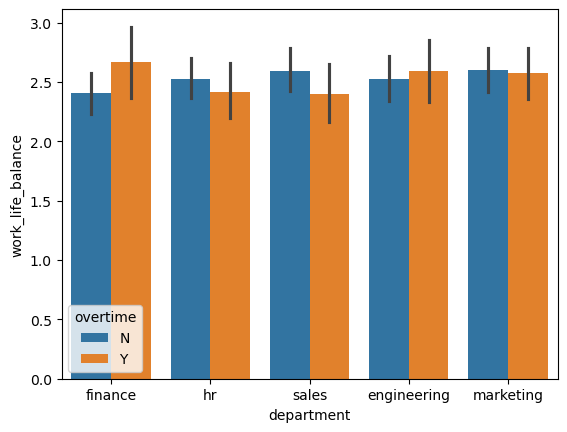

In [17]:
# 시각화
sns.barplot(data=churn_df, x='department', y='work_life_balance', hue='overtime')
답03 = 2

In [18]:
# 결측치 제거
# churn_df.info()
pre_df = churn_df.dropna(subset=["years_experience", "salary"])
# pre_df.isna().sum()
pre_df.reset_index(drop=True, inplace=True)
print(pre_df)
답04 =  "years_experience, salary"

      years_experience  salary education_level   department overtime  \
0                 15.0    54.6          master      finance        N   
1                  5.6   116.6        bachelor           hr        N   
2                 11.0    32.2             phd           hr        N   
3                 16.2    82.2             phd        sales        Y   
4                 12.4    97.7     high_school  engineering        N   
...                ...     ...             ...          ...      ...   
1009              19.2   113.5        bachelor  engineering        N   
1010              11.6   117.4     high_school           hr        Y   
1011              18.0    58.3     high_school    marketing        N   
1012              15.9    39.8          master      finance        Y   
1013               2.1   114.1             phd        sales        N   

      job_satisfaction  work_life_balance  attrition  
0                    3                  4          1  
1                    3   

In [19]:
# 부서별 직무 만족도 평균
pre_df.groupby('department')['job_satisfaction'].mean()
답05 = 4

In [20]:
# 부서별 이직률 분석
result = pd.crosstab(pre_df['department'], pre_df['attrition'], normalize='index')
print(result.round(2))
답06 = 'engineering'

attrition       0     1
department             
engineering  0.61  0.39
finance      0.67  0.33
hr           0.66  0.34
marketing    0.69  0.31
sales        0.73  0.27


In [21]:
# pre_df.info()
# print(pre_df.head())
print(pre_df['education_level'].value_counts())

# 사전 실행
edu_map = {
    'high_school': 0,
    'bachelor': 1,
    'master': 2, 
    'phd': 3
}
pre_df['education_level'] = pre_df['education_level'].map(edu_map)

# 원-핫 인코딩
encoding_df = pd.get_dummies(data=pre_df, columns=['department'], drop_first=True)
# encoding_df.info()
encoding_df['overtime'] = np.where(encoding_df['overtime']=='Y', 1, 0)
encoding_df

education_level
high_school    266
phd            265
master         253
bachelor       230
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   years_experience      1014 non-null   float64
 1   salary                1014 non-null   float64
 2   education_level       1014 non-null   int64  
 3   overtime              1014 non-null   object 
 4   job_satisfaction      1014 non-null   int64  
 5   work_life_balance     1014 non-null   int64  
 6   attrition             1014 non-null   int64  
 7   department_finance    1014 non-null   bool   
 8   department_hr         1014 non-null   bool   
 9   department_marketing  1014 non-null   bool   
 10  department_sales      1014 non-null   bool   
dtypes: bool(4), float64(2), int64(4), object(1)
memory usage: 59.5+ KB


C:\Users\LG\AppData\Local\Temp\ipykernel_18628\480570323.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_df['education_level'] = pre_df['education_level'].map(edu_map)


,years_experience,salary,education_level,overtime,job_satisfaction,work_life_balance,attrition,department_finance,department_hr,department_marketing,department_sales
0,15.0,54.6,2,0,3,4,1,True,False,False,False
1,5.6,116.6,1,0,3,2,1,False,True,False,False
2,11.0,32.2,3,0,4,2,1,False,True,False,False
3,16.2,82.2,3,1,1,3,1,False,False,False,True
4,12.4,97.7,0,0,2,3,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1009,19.2,113.5,1,0,1,1,1,False,False,False,False
1010,11.6,117.4,0,1,2,2,0,False,True,False,False
1011,18.0,58.3,0,0,2,4,0,False,False,True,False
1012,15.9,39.8,2,1,3,3,0,True,False,False,False


In [28]:
# 변수 선택
X = encoding_df.drop(columns='attrition', axis=1)
y = encoding_df['attrition']

# 데이터 분리
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=12
)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape
X_train

,years_experience,salary,education_level,overtime,job_satisfaction,work_life_balance,department_finance,department_hr,department_marketing,department_sales
538,8.7,78.4,2,0,2,3,False,True,False,False
341,1.7,87.4,3,0,4,3,True,False,False,False
854,17.4,39.4,2,0,3,4,True,False,False,False
607,6.3,57.1,0,1,2,2,False,True,False,False
771,16.5,102.2,3,0,1,4,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
241,14.5,103.9,2,1,3,2,False,False,False,False
253,8.9,86.9,2,0,1,1,False,False,False,True
390,12.4,64.6,1,0,3,2,False,False,False,True
667,10.6,37.1,0,1,2,4,False,False,False,True


In [29]:
# 데이터 표준화
from sklearn.preprocessing import StandardScaler

model = StandardScaler()
X_train = model.fit_transform(X_train)
X_test = model.transform(X_valid)
X_train

array([[-0.23052962,  0.12756115,  0.4074311 , ...,  1.82671793,
        -0.462679  , -0.49575773],
       [-1.44331498,  0.47104027,  1.29329335, ..., -0.54742989,
        -0.462679  , -0.49575773],
       [ 1.27678932, -1.36084837,  0.4074311 , ..., -0.54742989,
        -0.462679  , -0.49575773],
       ...,
       [ 0.41051406, -0.39910683, -0.47843116, ..., -0.54742989,
        -0.462679  ,  2.01711428],
       [ 0.09865497, -1.44862637, -1.36429341, ..., -0.54742989,
        -0.462679  ,  2.01711428],
       [-0.03994907,  1.07785339,  0.4074311 , ..., -0.54742989,
        -0.462679  ,  2.01711428]], shape=(811, 10))

In [31]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 11.1 MB/s  0:00:00


In [34]:
# 모델 학습
from lightgbm import LGBMClassifier

lgmbc = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.01, random_state=10)
lgmbc.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 266, number of negative: 545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 811, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.327990 -> initscore=-0.717289
[LightGBM] [Info] Start training from score -0.717289
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [39]:
# 예측 결과 비교, 성능 확인
from sklearn.metrics import accuracy_score, f1_score

lgbmc_predict = lgmbc.predict(X_test)

print("lgbmc_accuracy_score:", accuracy_score(y_valid, lgbmc_predict))
print("lgbmc_f1_score:", f1_score(y_valid, lgbmc_predict))

lgbmc_accuracy_score: 0.6650246305418719
lgbmc_f1_score: 0.0


C:\Users\LG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
# 딥러닝 라이브러리
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(10)

y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [47]:
# 모델 구조
model = Sequential()

model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(2, activation='softmax'))

# 모델 설정
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

# 모델 학습
model.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50


C:\Users\LG\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5203 - loss: 0.7570
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6079 - loss: 0.6707
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6486 - loss: 0.6344
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6584 - loss: 0.6186
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6708 - loss: 0.6074
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6782 - loss: 0.5983
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6893 - loss: 0.5910
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6967 - loss: 0.5839
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7004 - loss: 0.5777
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7065 - loss: 0.5721
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7090 - loss: 0.5664
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7078 - loss: 0.5619
